In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [4]:
def kmeans_image_segmentation(image_path, k_values):
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error loading image: {image_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, c = img.shape
    pixels = img.reshape((-1, 3))
    pixels = np.float32(pixels)

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixels)
        centers = kmeans.cluster_centers_

        plt.figure(figsize=(15, 3))
        plt.suptitle(f"{image_path}  |  k = {k}", fontsize=14)

        for i in range(k):
            cluster_img = np.ones_like(pixels) * 255
            cluster_img[labels == i] = centers[i]

            cluster_img = cluster_img.reshape((h, w, 3)).astype(np.uint8)

            plt.subplot(1, k, i + 1)
            plt.imshow(cluster_img)
            plt.axis('off')
            plt.title(f"Cluster {i + 1}")

        plt.show()


In [5]:
images = [
    "image_001.png",
    "image_002.png",
    "image_003.png",
    "image_004.png",
    "image_005.png",
    "image_006.png"
]

k_values = [2, 3, 4, 5]


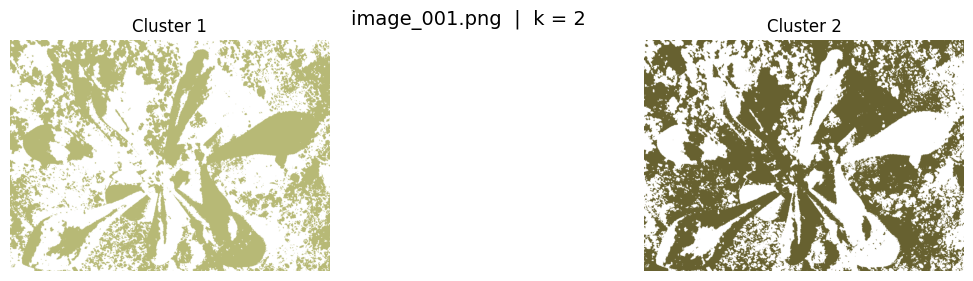

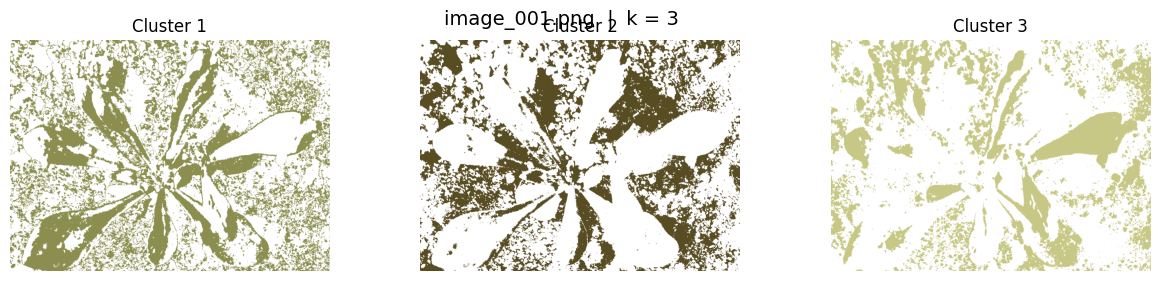

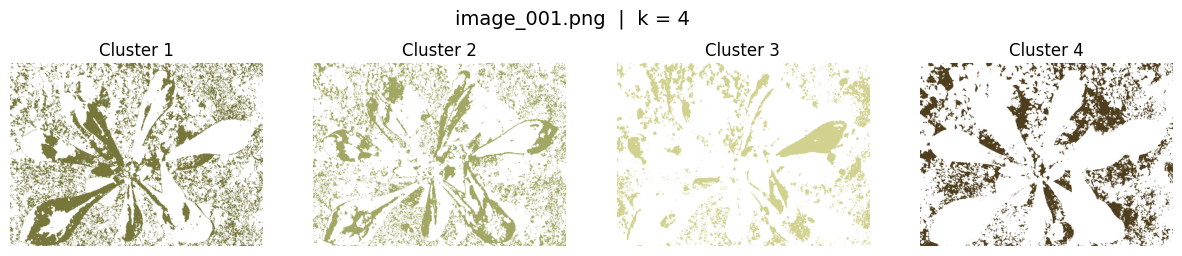

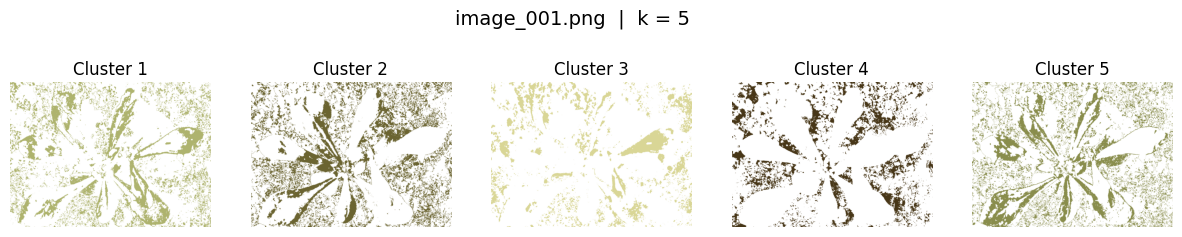

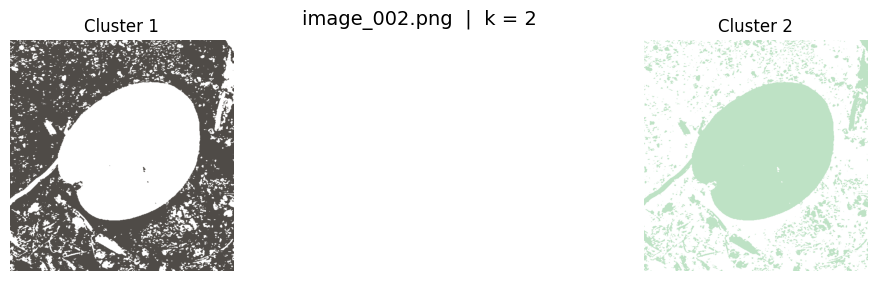

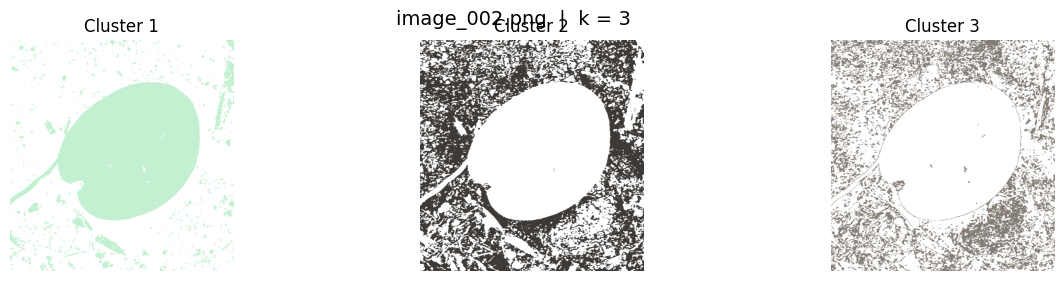

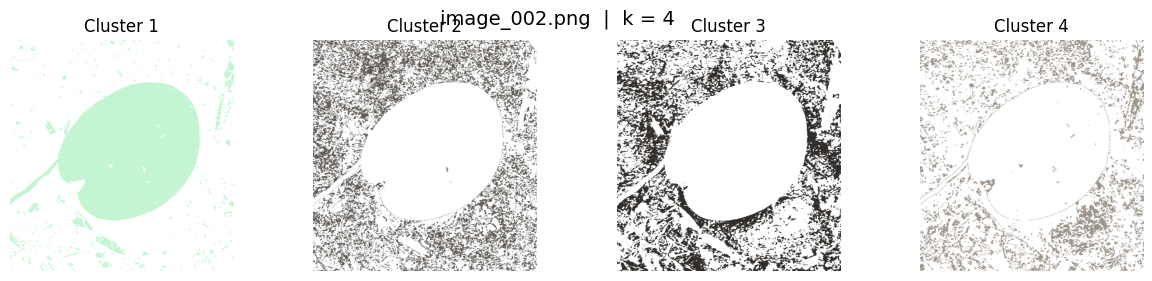

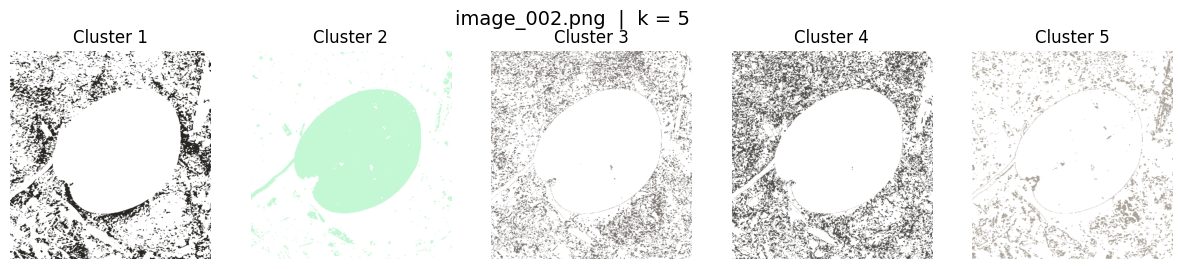

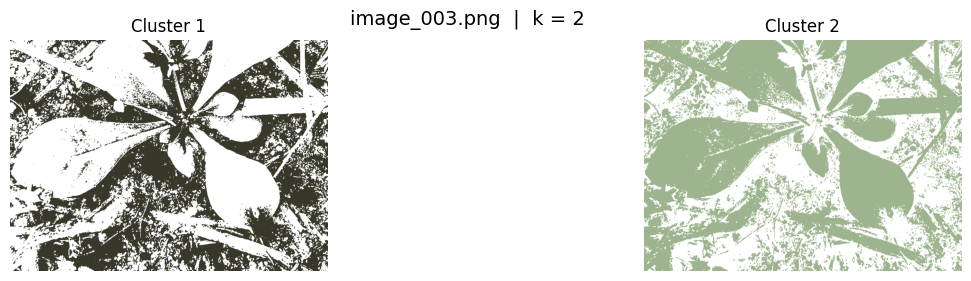

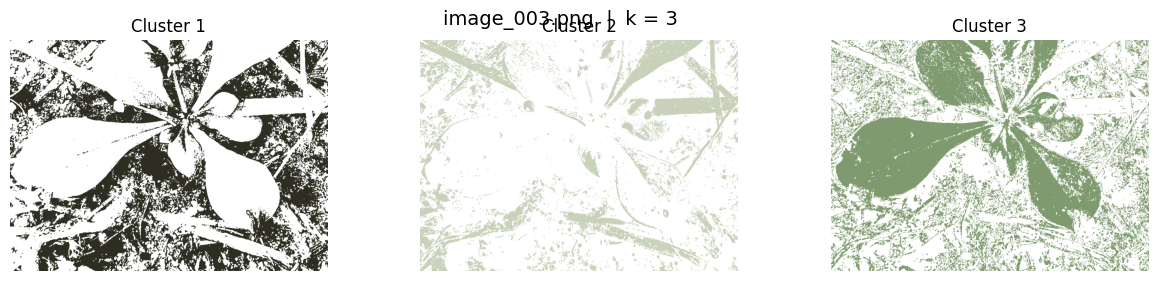

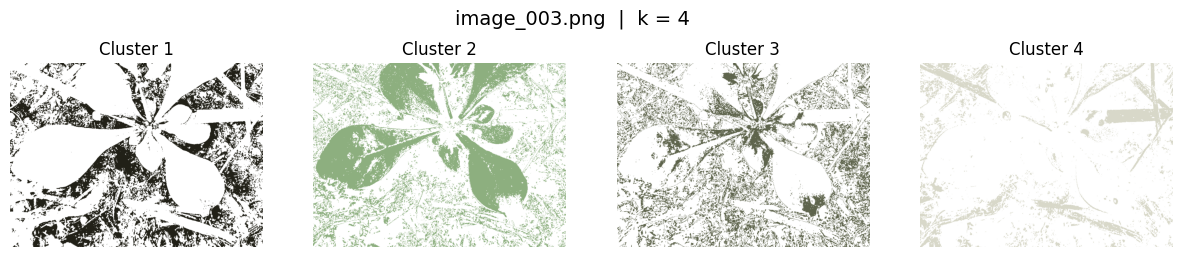

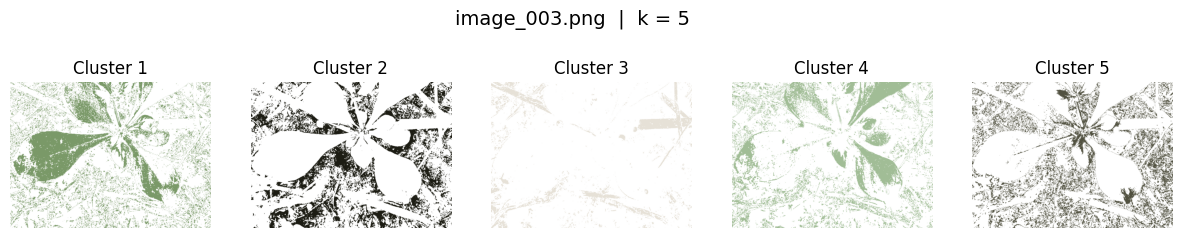

Error loading image: image_004.png


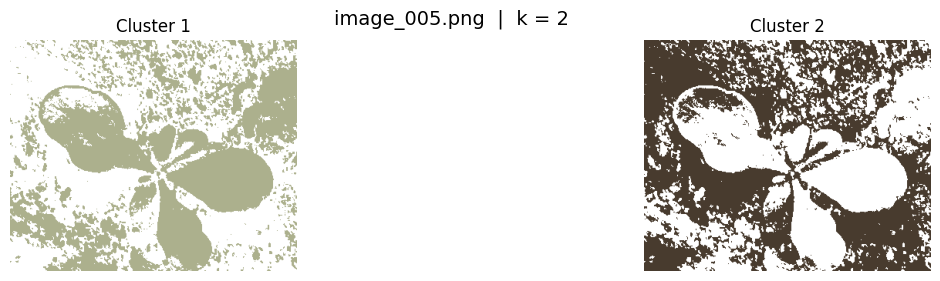

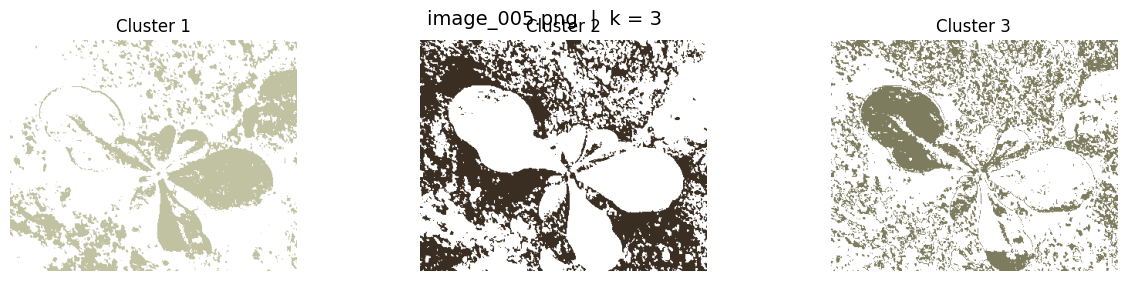

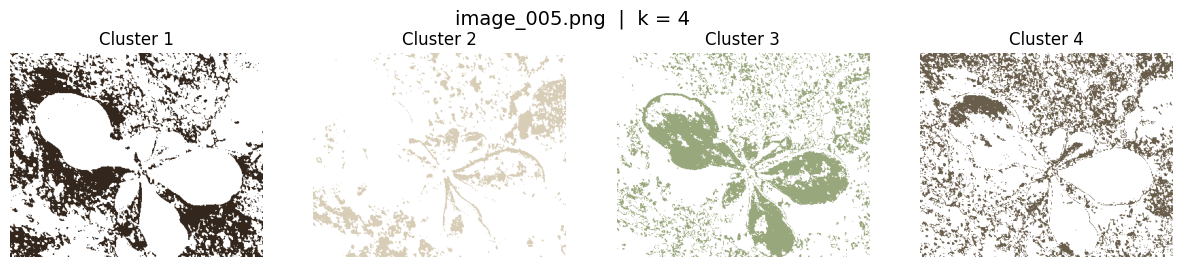

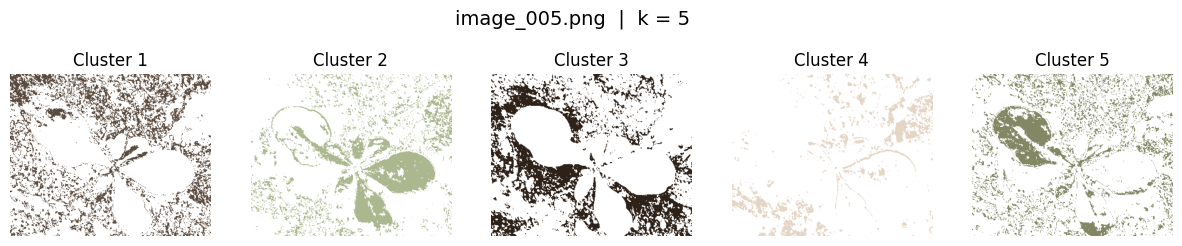

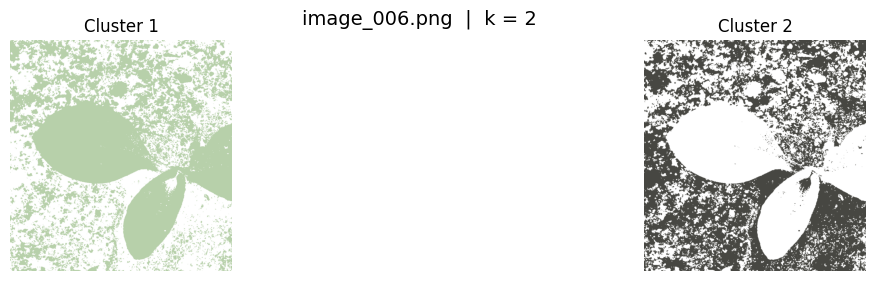

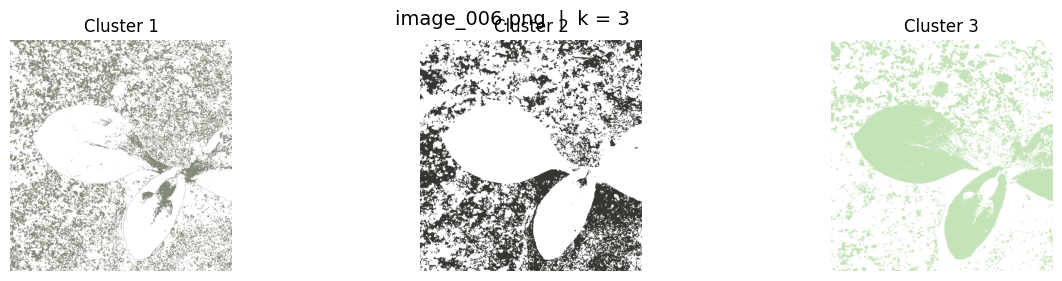

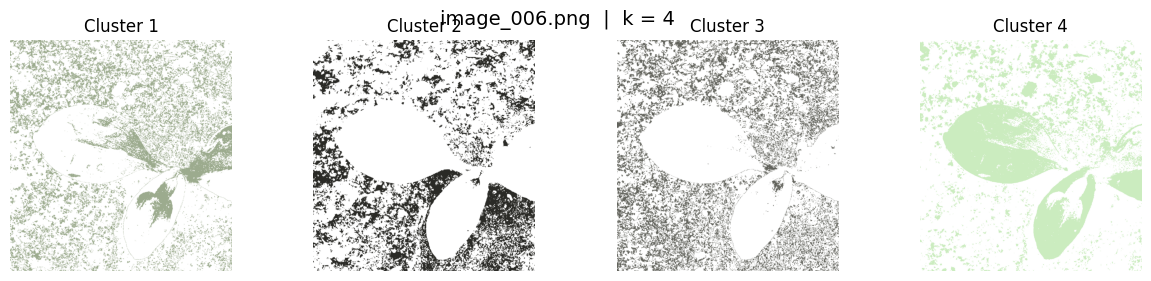

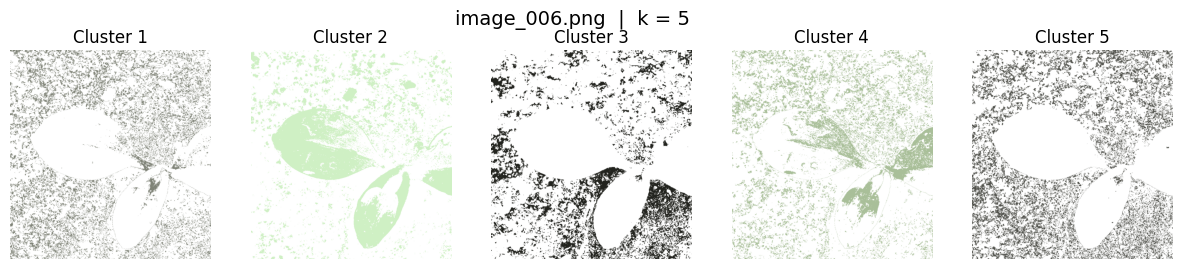

In [6]:
for img in images:
    kmeans_image_segmentation(img, k_values)
